Goal of this notebook is to 1) have subsurface figures in one place, and 2) add some new figures to define "responsive layer"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy import interpolate
import scipy.signal
from datetime import datetime as dt
import cmocean
import datetime
from matplotlib.dates import DateFormatter
import glob
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib as mpl
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import pandas as pd
import csv
myFmt = mdates.DateFormatter('%m-%d')
from matplotlib.gridspec import GridSpec
from scipy import stats

from ICECAPS_support_functions import *

In [3]:
def scatter_hist(x, y, ax, ax_histx, ax_histy, xbins, ybins, c=False, label=False, xvname=False, yvname=False, shape='o', ):

    # the scatter plot:
    ax.scatter(x, y, s=30, edgecolor=c, marker=shape, color="None", alpha=.45,) # label=label,

    combined_mask = np.ma.mask_or(x.mask, y.mask)
    # add best fit line
    if True:#xvname=='ts' or xvname=='rlds':
        xlr = x[~combined_mask]#][~np.isnan(y)]
        ylr = y[~combined_mask]#[~np.isnan(y)]

        # print(np.shape(xlr[~xlr.mask]), np.shape(ylr[~xlr.mask]))
        if xlr[~xlr.mask].count()==0:
            return
        xvar_lr = stats.linregress(np.squeeze(xlr[~xlr.mask]), np.squeeze(ylr[~xlr.mask]))
        ax.plot(np.unique(xlr), [xx*xvar_lr.slope+xvar_lr.intercept for xx in np.unique(xlr)],
            c=c, zorder=10, lw=1,
            label='{a:.2f} ({b:.2f})'.format(a=xvar_lr.slope, b=xvar_lr.rvalue**2))
                
        ax.plot(np.unique(xlr), [xx*xvar_lr.slope+xvar_lr.intercept for xx in np.unique(xlr)],
            c='k', zorder=20, lw=1,)

    if type(ax_histx)!=type(False):
        ax_histx.hist(x[~combined_mask].flatten(), bins=xbins, color=c, 
                    label=f'{np.mean(x[~combined_mask]):.2f} ({np.std(x[~combined_mask]):.2f})',
                    density=True)
        # no labels
        ax_histx.tick_params(axis="x", labelbottom=False)

    if type(ax_histy)!=type(False):
        ax_histy.hist(y[~combined_mask].flatten(), bins=ybins, orientation='horizontal',
                    color=c, label=f'{np.mean(y[~combined_mask]):.2f} ({np.std(y[~combined_mask]):.2f})', density=True)
        ax_histy.tick_params(axis="y", labelleft=False)



    return

In [4]:
# fversion = 'v4.2_20250730_sfcdif+4.0_ksi15.0'
fversion = 'v4.3_20250815_sfcdif+4.0_ksi16.0'

simba_data = open_corrected_simba_temps(fversion)
print(simba_data.keys())
simba_temps = simba_data['temperature']
simba_dates = simba_data['dates']
simba_depths = simba_data['height']
simba_sfc = simba_data['snow_surface']

simba_seconds = datetimes_to_seconds(simba_dates)

depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_depths, simba_temps, simba_sfc)
dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

avg_diurnal_dTdz = get_diurnal_cycle(simba_dates, dTdz_rel_sfc)
avg_diurnal_T = get_diurnal_cycle(simba_dates, temps_rel_sfc)
std_diurnal_T = get_diurnal_cycle(simba_dates, temps_rel_sfc, stat='std')

plt_tod = get_simba_time_of_day(simba_dates)

dict_keys(['seconds', 'temperature', 'height', 'snow_surface', 'dates'])


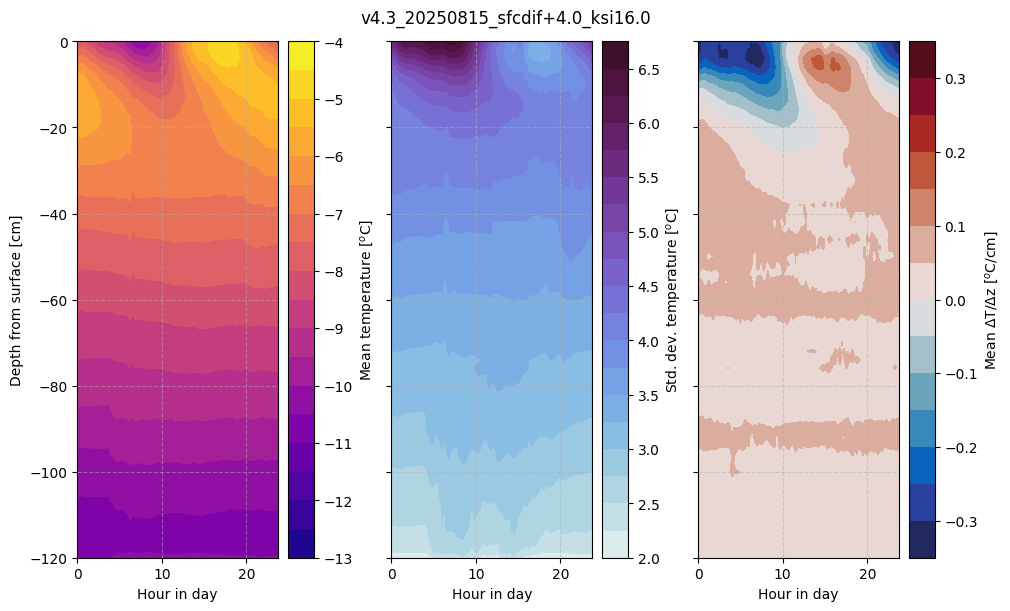

In [5]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]', 'Mean $\Delta$T/$\Delta$z [$^o$C/cm]']
levels = [np.arange(-13,-3.6,.5), np.arange(2,7,.25), np.arange(-.35,.351,.05)]
cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.balance]

for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_T, std_diurnal_T, avg_diurnal_dTdz])):
    cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])
    plt.colorbar(cb, label=cbar_labels[i], ax=ax)

    ax.set_ylim(-120,0)
    
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

axs[0].set_ylabel('Depth from surface [cm]')
fig.suptitle(fversion)
plt.show()

### defining responsive layer: running std devation with depth

In [6]:
# simba_temps = simba_data['temperature']
# simba_dates = simba_data['dates']
# simba_depths = simba_data['height']
# simba_sfc = simba_data['snow_surface']

# simba_seconds = datetimes_to_seconds(simba_dates)

simba_dTdz = np.gradient(simba_temps, simba_depths, axis=1)
simba_dTdt = np.gradient(simba_temps, simba_seconds, axis=0)

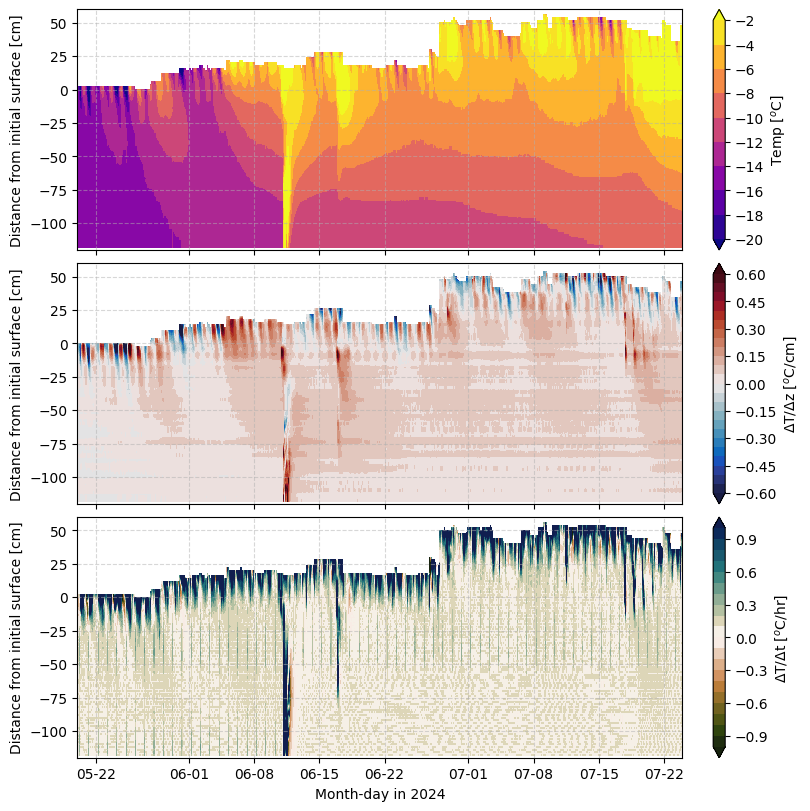

In [7]:
fig, axs = plt.subplots(3, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [simba_temps, simba_dTdz, simba_dTdt*60.*60.]
plt_labels = ['Temp [$^o$C]', '$\Delta$T/$\Delta$z [$^o$C/cm]', '$\Delta$T/$\Delta$t [$^o$C/hr]']
plt_cmaps = [plt.cm.plasma, cmocean.cm.balance, cmocean.cm.tarn]
plt_levs = [np.arange(-20,0,2), np.arange(-.6,.61,.05), np.arange(-1,1.1,.1)]


for i, ax in enumerate(axs.ravel()):
    cb = ax.contourf(simba_dates, simba_depths, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend='both')
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-120,60)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

Want running standard deviation - relative to surface and simba?

In [8]:
# depth_rel_sfc
# temps_rel_sfc
# dTdz_rel_sfc


def calc_running_stdev(data_in, window=4*24):
    """ window is the window length in time steps, so 4 observations for 24 hours
    """
        
    for i in range(data_in.shape[0]):

        try:
            time_step_var = np.ma.var(np.ma.masked_invalid(data_in.copy()[i-int(window/2):i+int(window/2)+1,:]), axis=0)
        except:
            time_step_var = np.full(var.shape[0], -999)

        if i==0:
            rolling_var_from_vert_win = time_step_var[np.newaxis,:]
        else:
            rolling_var_from_vert_win = np.ma.concatenate((rolling_var_from_vert_win, time_step_var[np.newaxis,:]))
            
    
    return rolling_var_from_vert_win

#### Relative to SIMBA

In [9]:
temps_std_24 = calc_running_stdev(simba_temps, window=4*24)
dTdz_std_24 = calc_running_stdev(simba_dTdz, window=4*24)

temps_std_48 = calc_running_stdev(simba_temps, window=4*48)
dTdz_std_48 = calc_running_stdev(simba_dTdz, window=4*48)

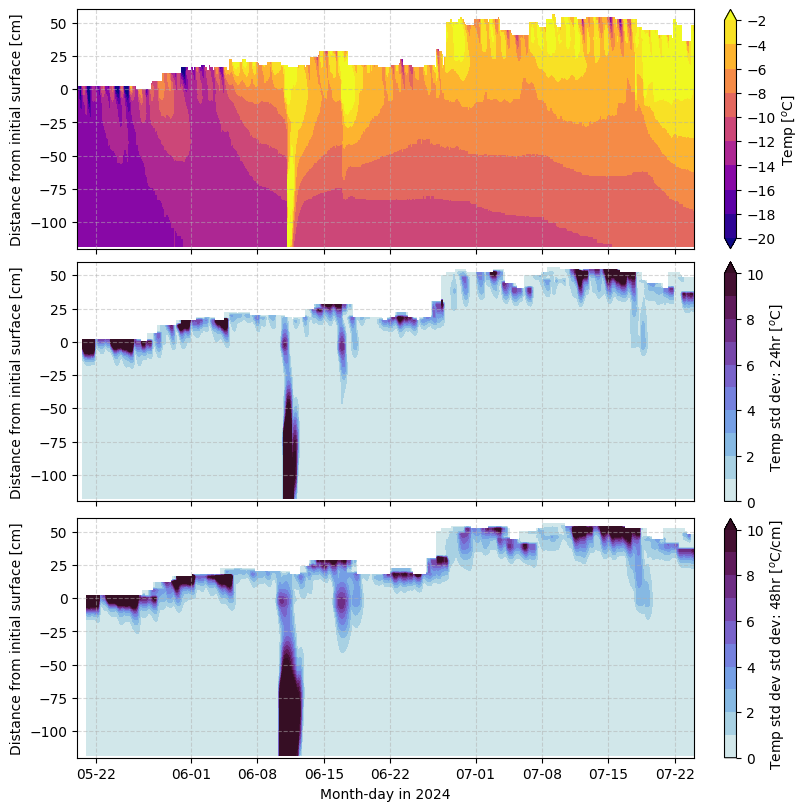

In [10]:
fig, axs = plt.subplots(3, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [simba_temps, temps_std_24, temps_std_48]
plt_labels = ['Temp [$^o$C]', 'Temp std dev: 24hr [$^o$C]', 'Temp std dev std dev: 48hr [$^o$C/cm]']
plt_cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.dense]
plt_levs = [np.arange(-20,0,2), np.arange(0,10.1,1), np.arange(0,10.1,1)]
plt_extends = ['both','max','max']

for i, ax in enumerate(axs.ravel()):
    cb = ax.contourf(simba_dates, simba_depths, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend=plt_extends[i])
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-120,60)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

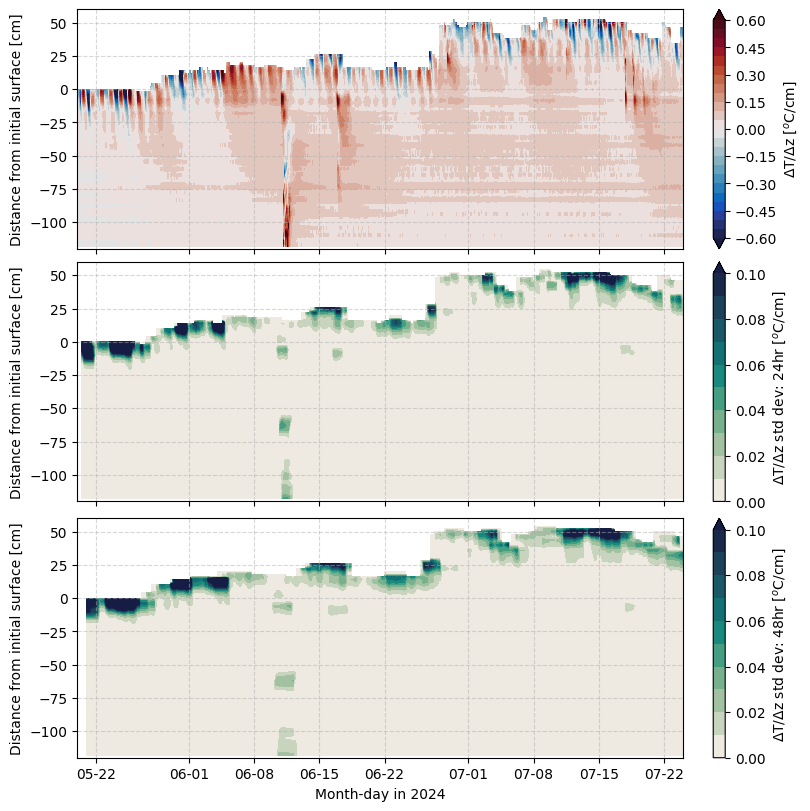

In [11]:
fig, axs = plt.subplots(3, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [simba_dTdz, dTdz_std_24, dTdz_std_48]
plt_labels = ['$\Delta$T/$\Delta$z [$^o$C/cm]', '$\Delta$T/$\Delta$z std dev: 24hr [$^o$C/cm]', '$\Delta$T/$\Delta$z std dev: 48hr [$^o$C/cm]']
plt_cmaps = [cmocean.cm.balance, cmocean.cm.tempo, cmocean.cm.tempo]
plt_levs = [np.arange(-.6,.61,.05), np.arange(0,.11,.01), np.arange(0,.11,.01)]
plt_extends = ['both','max','max']

for i, ax in enumerate(axs.ravel()):
    cb = ax.contourf(simba_dates, simba_depths, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend=plt_extends[i])
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-120,60)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

#### Relative to the surface

In [12]:
temps_rel_sfc_std = calc_running_stdev(temps_rel_sfc, window=4*24)

In [13]:
dTdz_rel_sfc_std = calc_running_stdev(dTdz_rel_sfc, window=4*24)

In [14]:
temps_rel_sfc_std_48 = calc_running_stdev(temps_rel_sfc, window=4*48)
dTdz_rel_sfc_std_48 = calc_running_stdev(dTdz_rel_sfc, window=4*48)

In [15]:
temps_rel_sfc_std_week = calc_running_stdev(temps_rel_sfc, window=4*24*7)
dTdz_rel_sfc_std_week = calc_running_stdev(dTdz_rel_sfc, window=4*24*7)

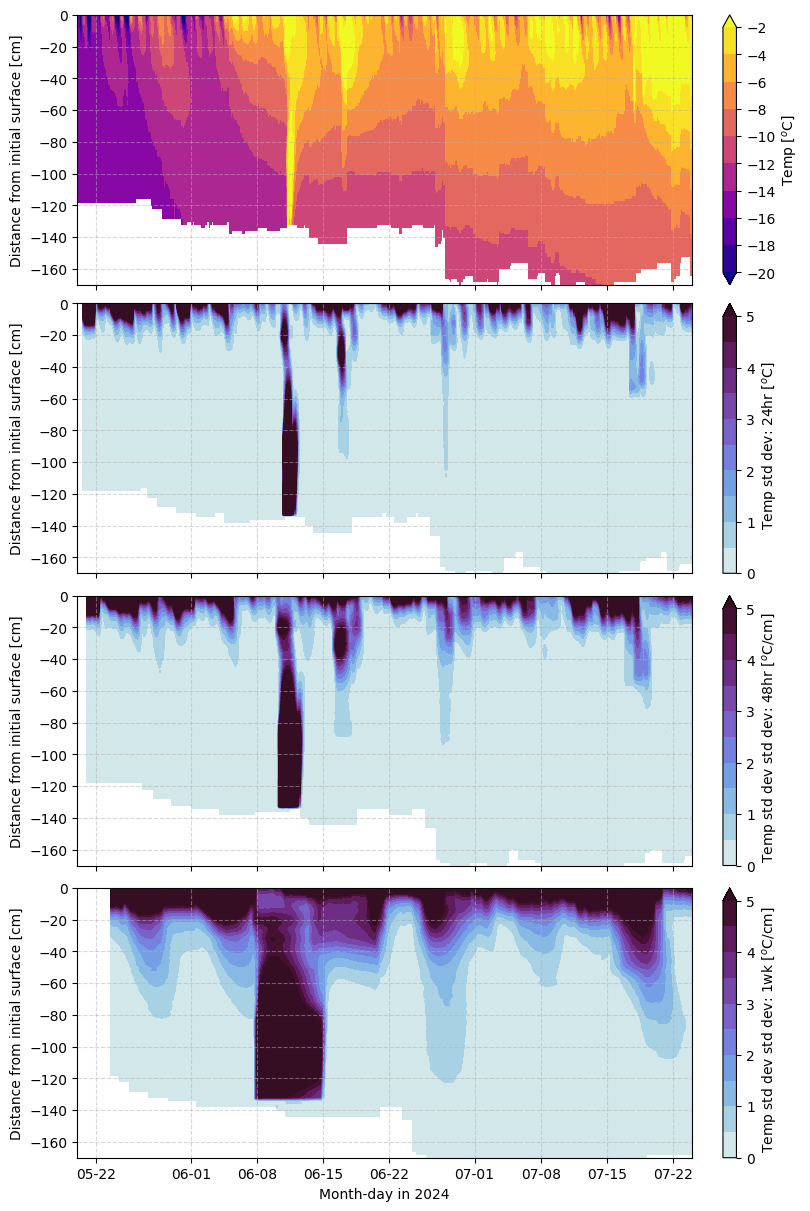

In [16]:
fig, axs = plt.subplots(4, figsize=(8,12), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [temps_rel_sfc, temps_rel_sfc_std, temps_rel_sfc_std_48, temps_rel_sfc_std_week]
plt_labels = ['Temp [$^o$C]', 'Temp std dev: 24hr [$^o$C]', 
              'Temp std dev std dev: 48hr [$^o$C/cm]', 'Temp std dev std dev: 1wk [$^o$C/cm]']
plt_cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.dense, cmocean.cm.dense]
# plt_levs = [np.arange(-20,0,2), np.arange(0,10.1,1), np.arange(0,10.1,1)]
plt_levs = [np.arange(-20,0,2), np.arange(0,5.1,.5), np.arange(0,5.1,.5), np.arange(0,5.1,.5)]

plt_extends = ['both','max','max', 'max']

for i, ax in enumerate(axs.ravel()):
    cb = ax.contourf(simba_dates, depth_rel_sfc, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend=plt_extends[i])
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-170,0)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

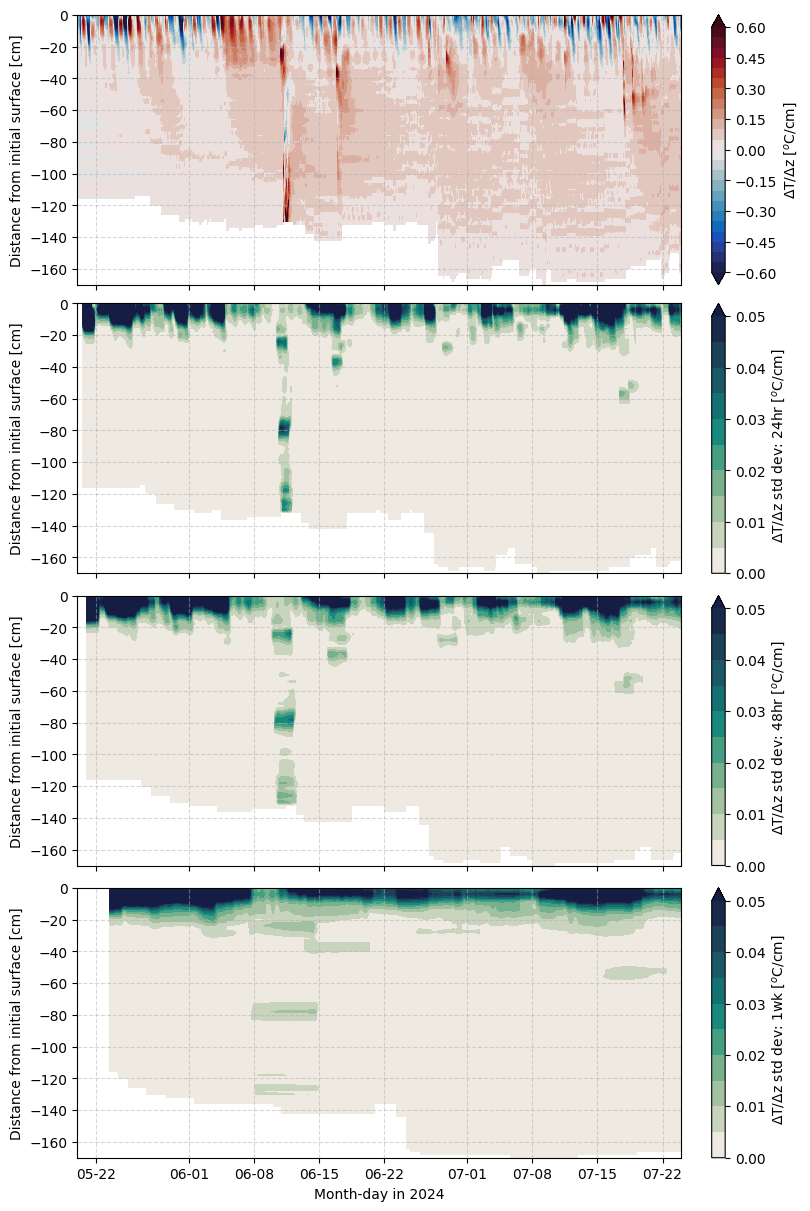

In [17]:
fig, axs = plt.subplots(4, figsize=(8,12), sharey=True, sharex=True, constrained_layout=True)

plt_vars = [dTdz_rel_sfc, dTdz_rel_sfc_std, dTdz_rel_sfc_std_48, dTdz_rel_sfc_std_week]
plt_labels = ['$\Delta$T/$\Delta$z [$^o$C/cm]', '$\Delta$T/$\Delta$z std dev: 24hr [$^o$C/cm]', 
              '$\Delta$T/$\Delta$z std dev: 48hr [$^o$C/cm]', '$\Delta$T/$\Delta$z std dev: 1wk [$^o$C/cm]']
plt_cmaps = [cmocean.cm.balance, cmocean.cm.tempo, cmocean.cm.tempo, cmocean.cm.tempo]
# plt_levs = [np.arange(-.6,.61,.05), np.arange(0,.11,.01), np.arange(0,.11,.01)]
plt_levs = [np.arange(-.6,.61,.05), np.arange(0,.051,.005), np.arange(0,.051,.005), np.arange(0,.051,.005)]

plt_extends = ['both','max','max','max']

for i, ax in enumerate(axs.ravel()): 
    cb = ax.contourf(simba_dates, depth_rel_sfc, np.swapaxes(plt_vars[i],0,1), cmap=plt_cmaps[i], levels=plt_levs[i],
                    extend=plt_extends[i])
    plt.colorbar(cb, ax=ax, label=plt_labels[i])
    
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel('Distance from initial surface [cm]')

    ax.xaxis.set_major_formatter(myFmt)

axs[0].set_ylim(-170,0)
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

### Recreate old plots relative to the surface

In [18]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)

In [19]:
skin_temp = asfs_data_lev2['skin_temp']
sleigh_dates = asfs_data_lev2['dates']
sleigh_seconds = datetimes_to_seconds(sleigh_dates)

skinT_sfc_timesteps = interpolate_and_mask(skin_temp, sleigh_seconds, simba_seconds)-273.15
skinT_sfc_timesteps = np.ma.masked_outside(skinT_sfc_timesteps, -30, 5)

Need to detrend before correlating?

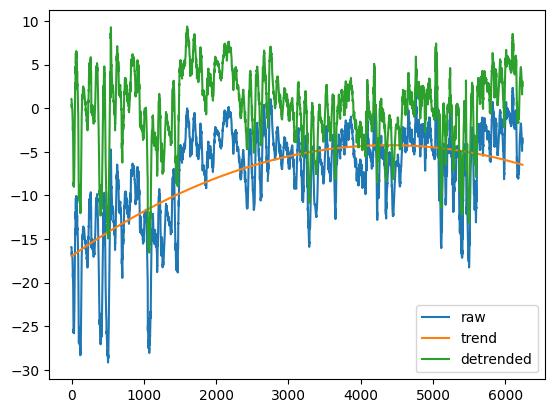

In [20]:



# ## inefficent detrending because there are nans

x = np.arange(temps_rel_sfc.shape[0])

slopes_with_depth = []

for i in range(temps_rel_sfc.shape[1]):
    y = temps_rel_sfc[:,i]

    try:
        coeff = np.ma.polyfit(x, y, 2)
    except:
        detrend_temps = np.ma.concatenate( (detrend_temps, np.full(x.shape, np.nan)[:, np.newaxis]), axis=1 )
        slopes_with_depth.append(np.nan)
        continue
    # no need to use the original x values here just for visualizing the polynomial
    x_poly = np.linspace(x.min(), x.max())
    y_poly = np.polyval(coeff, x_poly)
    
    # we need the original x values here, so we can remove the trend from all points
    trend = np.polyval(coeff, x)
    t_detrend = y - trend
    # note that simply subtracting the trend might not be enough for other data sets
    slopes_with_depth.append(coeff[0])
        
    if i==0:
        detrend_temps = t_detrend[:, np.newaxis]
        ## check detrending
        plt.plot(x, y, label='raw')
        plt.plot(x, trend, label='trend')
        plt.plot(x, t_detrend, label='detrended')
        plt.legend(loc='best')
        plt.show()

    else:
        detrend_temps = np.ma.concatenate( (detrend_temps, t_detrend[:, np.newaxis]), axis=1 )

detrend_temps = np.ma.masked_invalid(detrend_temps)


In [21]:
temp_corrs = np.ma.corrcoef(temps_rel_sfc[:,0], temps_rel_sfc[:,1:].T)[0][1:]
temp_corrs_skin = np.ma.corrcoef(skinT_sfc_timesteps, temps_rel_sfc[:,:].T)[0][1:]

In [22]:
temp_corrs_det = np.ma.corrcoef(detrend_temps[:,0], detrend_temps[:,1:].T)[0][1:]
temp_corrs_skin_det = np.ma.corrcoef(skinT_sfc_timesteps, detrend_temps[:,:].T)[0][1:]

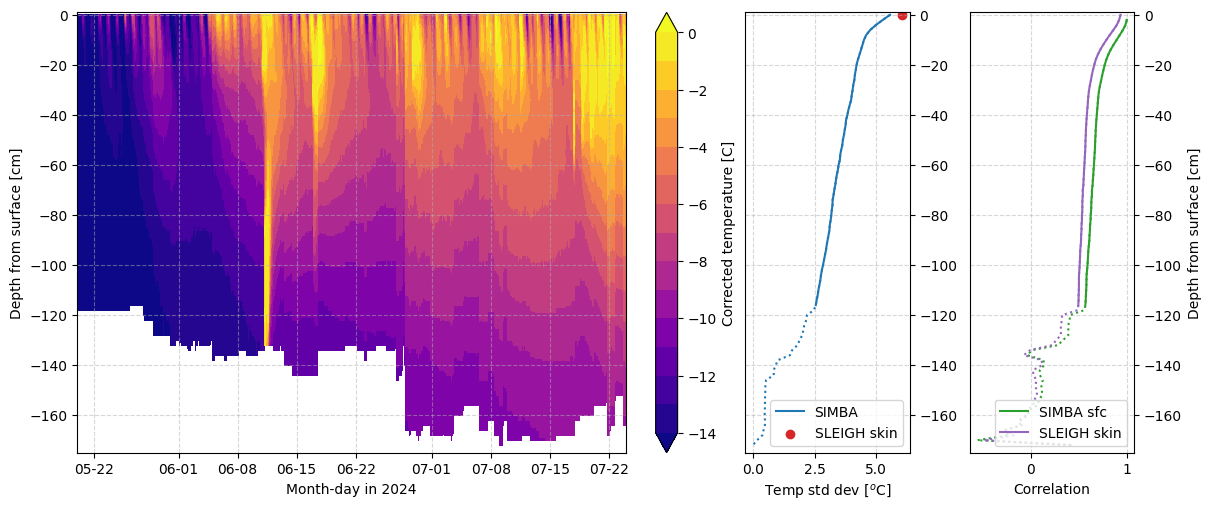

In [23]:


temp_std_profile = temps_rel_sfc.std(axis=0)

## believe that sharp drop in std dev and correlations are due to fewer points than higher up, 
## so show different sections in plot that either have data for every time step or not
temp_counts = temps_rel_sfc.count(axis=0)
l = temps_rel_sfc.count(axis=0)[0]
temp_std_full = np.ma.masked_where(temp_counts<l, temp_std_profile)

fig, axs = plt.subplots(1, 3, figsize=(12,5), gridspec_kw=dict(width_ratios=[4,1.2,1.2]), constrained_layout=True)

cb = axs[0].contourf(simba_dates, depth_rel_sfc, np.swapaxes(temps_rel_sfc,0,1), cmap='plasma',
                    levels=np.arange(-14,0.1,1), extend='both')
plt.colorbar(cb, label='Corrected temperature [C]', ax=axs[0])

axs[1].plot(temp_std_profile, depth_rel_sfc, ls=':', c='tab:blue')

axs[1].plot(temp_std_full, depth_rel_sfc, label='SIMBA', c='tab:blue')

axs[1].scatter(skinT_sfc_timesteps.std(), 0, c='tab:red', label='SLEIGH skin')

axs[1].legend(loc='lower right')

axs[1].set_xlabel('Temp std dev [$^o$C]')

axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()



axs[2].plot(temp_corrs, depth_rel_sfc[1:],ls=':', c='tab:green')
axs[2].plot(temp_corrs_skin, depth_rel_sfc, ls=':', c='tab:purple')

axs[2].plot(temp_corrs[~temp_std_full[1:].mask], depth_rel_sfc[1:][~temp_std_full[1:].mask], label='SIMBA sfc', c='tab:green')
axs[2].plot(temp_corrs_skin[~temp_std_full.mask], depth_rel_sfc[~temp_std_full.mask], label='SLEIGH skin', c='tab:purple')

axs[2].legend(loc='lower right')

axs[2].set_xlabel('Correlation')

axs[2].yaxis.set_label_position("right")
axs[2].yaxis.tick_right()

axs[0].xaxis.set_major_formatter(myFmt)
axs[0].set_xlabel('Month-day in 2024')

for i, ax in enumerate(axs.ravel()):
    ax.grid(ls='--', alpha=.5)
    ax.set_ylim(-175,1)
    if i!=1:
        ax.set_ylabel('Depth from surface [cm]')

# plt.tight_layout()
# plt.savefig('/home/asledd/ICECAPS/simba_solar_correction_figs/Raven_corrected-simba_20ks_0.5nir_-6sfc_temp-rel-to-sfc_std-dev-depths.png', dpi=250)

plt.show()

In [24]:
def calc_sw_ext(sw_sfc, kappa, depths_in, f_nir=0.5):
    """ swc_sfc is net SW from the atmosphere (SWD-SWU) 
    kappa is snow extinction coefficient, which is going to be used as a tuning parameter
    f_nir is the fraction of SW that is assumed to be NIR (as opposed to visible)
    depths is assumed to be centimeters below the surface with intervals of 2cm, i.e., 2, 4, 6 etc 
    should depths start at 0 or 2? """

    ## so that absorbed SW, clacluated as the difference between levels, covers the temperature
    # depths_in += .01

    ## transmitted SW at each level
    print('SWT shapes',  np.shape(sw_sfc), np.shape(kappa), np.shape(depths_in))
    sw_t = (1-f_nir)*sw_sfc*np.ma.exp(-kappa*np.abs(depths_in))
    print('SWT out shape', sw_t.shape)

    ## absorbed SW at each level
    # indexing will need to change to use SWN timeseries
    sw_a = sw_t[:,:-1] - sw_t[:,1:]

    sfc_sw_a = sw_sfc[:,0]-sw_t[:,1]

    sw_a = np.concatenate((sfc_sw_a[:, np.newaxis], sw_a), axis=1)
    
    return sw_a, sw_t

In [25]:
swn = asfs_data_lev2['net_short_hemisp']
## are very high values real??
swn_sfc_timesteps = np.ma.masked_outside(interpolate_and_mask(swn, sleigh_seconds, simba_seconds), -100, 200)


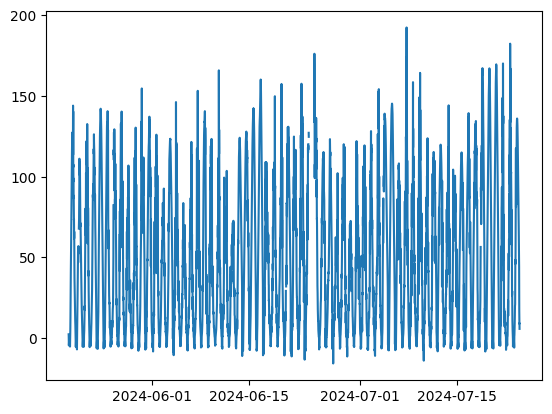

In [26]:
plt.plot(simba_dates, swn_sfc_timesteps)

In [27]:
# make simba heights/depths relative to surface
sfc_height_2d = np.repeat(simba_sfc[:,np.newaxis], depth_rel_sfc.shape[0], axis=1)

# depth_rel_sfc

depth_rel_sfc_m = np.ma.masked_greater(depth_rel_sfc, 0)/100.

simba_swn_2d = np.repeat(swn_sfc_timesteps[:,np.newaxis], sfc_height_2d.shape[1], axis=1)

ks_vis = 15.

    
simba_swa, simba_swt = calc_sw_ext(simba_swn_2d, ks_vis, depth_rel_sfc_m, f_nir=0.5)

SWT shapes (6239, 100) () (100,)
SWT out shape (6239, 100)


In [28]:
simba_swt[simba_swt.mask] = 0.

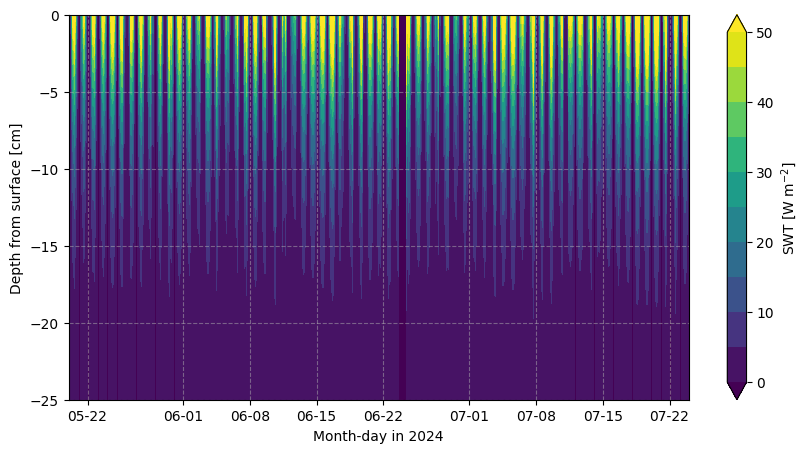

In [29]:
fig, ax = plt.subplots(1, figsize=(10,5))
cb = ax.contourf(simba_dates, depth_rel_sfc, np.swapaxes(simba_swt, 0, 1), levels=np.arange(0,51,5), extend='both')
plt.colorbar(cb, label='SWT [W m$^{-2}$]')
ax.set_ylim(-25,0)
ax.set_ylabel('Depth from surface [cm]')
ax.grid(alpha=.5, ls='--')
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

plt.show()

## Claculation and comparison of dT/dz and dT/dz between SIMBA and SLEIGH skin

Is the result similar, at least qualitatively, calculating dT/dz and dT/dt over 30cm using skin and surface temperatures?

In [30]:
simba_sfc = temps_rel_sfc[:,0]
# sleigh_skin = skinT_sfc_timesteps
simba_30cm = np.squeeze(temps_rel_sfc[:,np.where(depth_rel_sfc==-30)[0]])

time_diff = 2.*(simba_seconds[2:] - simba_seconds[:-2])


In [31]:
sub_flux_comparisons = {}

layer_depth = 0.3

for sfc_temp, label in zip([simba_sfc, skinT_sfc_timesteps], ['simba','sleigh']):
    sub_flux_comparisons[label] = {'T':sfc_temp}

    sub_flux_comparisons[label]['dTdz'] = (sfc_temp - simba_30cm)/(0.-layer_depth)

    temp_diff = sfc_temp[2:] - sfc_temp[:-2] + simba_30cm[2:] - simba_30cm[:-2]
    
    sub_flux_comparisons[label]['dTdt'] = temp_diff/time_diff

In [32]:
for instrument in ['simba','sleigh']:
    for variable in ['T','dTdz','dTdt']:
        print(instrument, variable, np.shape(sub_flux_comparisons[instrument][variable]))

simba T (6239,)
simba dTdz (6239,)
simba dTdt (6237,)
sleigh T (6239,)
sleigh dTdz (6239,)
sleigh dTdt (6237,)


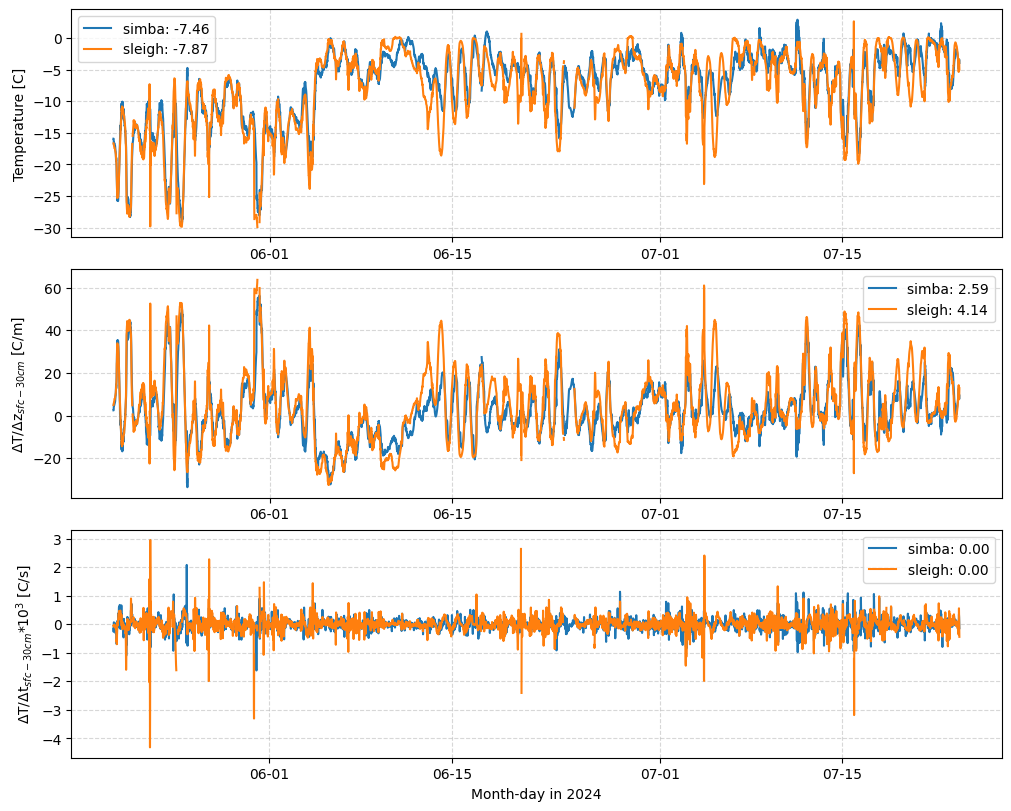

In [33]:
fig, axs = plt.subplots(3, figsize=(10,8), constrained_layout=True)

for instrument in ['simba','sleigh']:
    for ax, variable in zip(axs.ravel(), ['T','dTdz','dTdt']):
        data = sub_flux_comparisons[instrument][variable]
        if variable=='dTdt':
            ax.plot(simba_dates[1:-1], data*10**3, label=f'{instrument}: {np.nanmean(data*10**3):.2f}')
        else:
            ax.plot(simba_dates, data, label=f'{instrument}: {np.nanmean(data):.2f}')

ylabels = ['Temperature [C]', '$\Delta$T/$\Delta$z$_{sfc-30cm}$ [C/m]', '$\Delta$T/$\Delta$t$_{sfc-30cm}$*10$^3$ [C/s]']
for i, ax in enumerate(axs.ravel()):
    ax.grid(alpha=.5, ls='--')
    ax.set_ylabel(ylabels[i])
    ax.xaxis.set_major_formatter(myFmt)
    ax.legend(loc='best')
    
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

Correlation 0.931580093105433


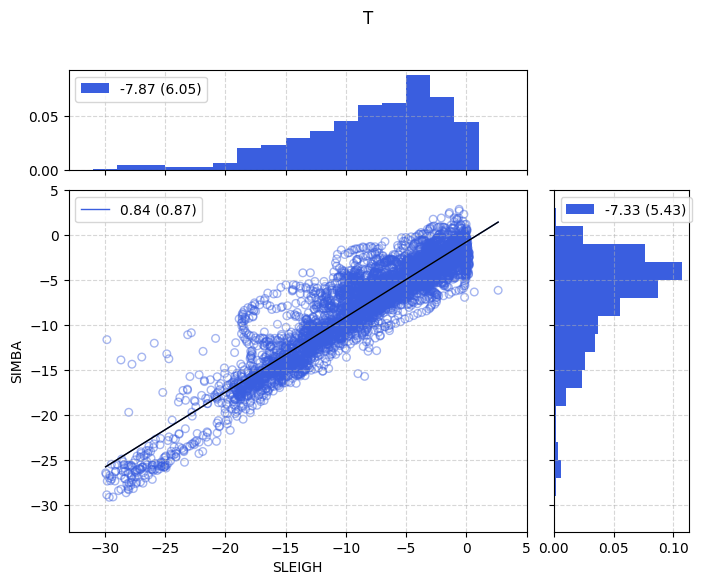

Correlation 0.8952681937714843


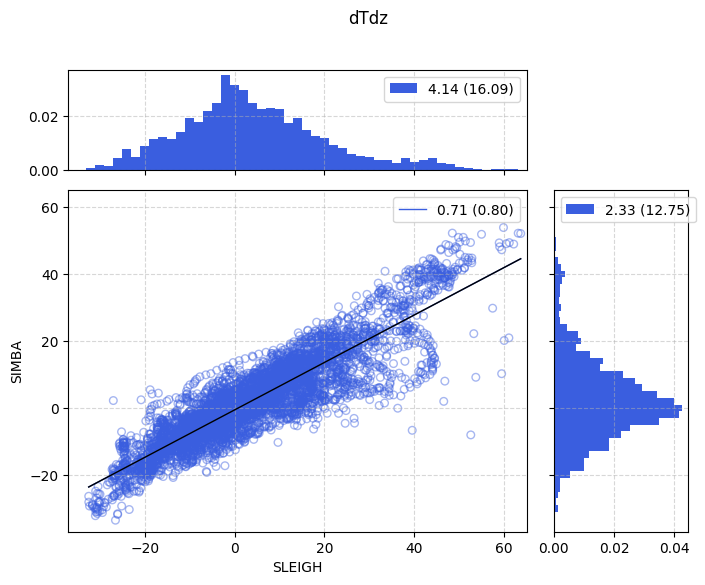

Correlation 0.4816728531392445


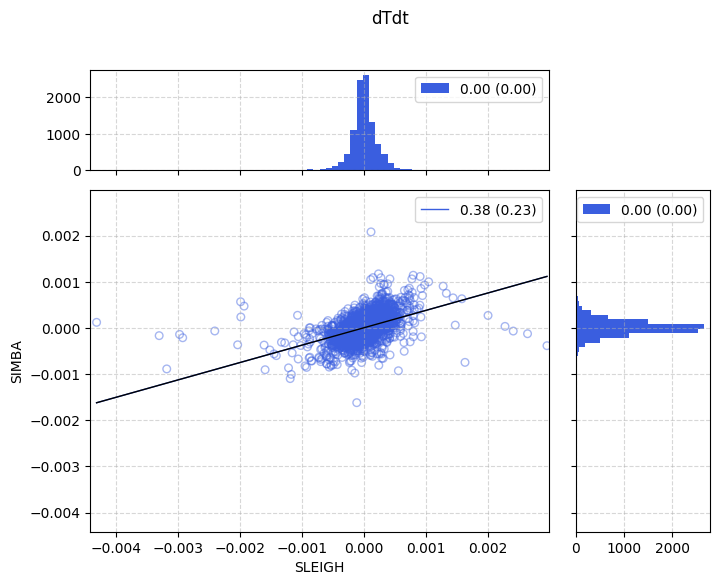

In [34]:
# bins for histograms

# variable = 'T'

for variable in ['T','dTdz','dTdt']:
# for variable in ['dTdt']:

    x_var = sub_flux_comparisons['sleigh'][variable].copy()
    y_var = sub_flux_comparisons['simba'][variable].copy()

    print('Correlation', np.ma.corrcoef(x_var, y_var)[0][1])

    if variable=='dTdt':
        # x_var *= 10
        # y_var *= 10

        pad = 0.0001
        bin_width = .0001
        bins = np.arange( np.minimum(np.ma.min(x_var), np.ma.min(y_var)), \
                          np.maximum(np.ma.max(x_var), np.ma.max(y_var)), bin_width) 
    else:
        pad = 2
        bin_width = 2

        bins = np.arange( round(np.minimum(np.ma.min(x_var), np.ma.min(y_var)))-1, \
                          round(np.maximum(np.ma.max(x_var), np.ma.max(y_var)))+1, bin_width) 
          
    # make figure
    fig = plt.figure(figsize=(8,6))
    gs = GridSpec(4, 4)
    
    ax_scatter = fig.add_subplot(gs[1:4, 0:3])
    ax_hist_x = fig.add_subplot(gs[0, 0:3])
    ax_hist_y = fig.add_subplot(gs[1:4, 3])
    
    
    scatter_hist(x_var, y_var, ax_scatter, 
                     ax_hist_x, ax_hist_y, bins, bins, 
                     c='#3A5EDF')
    
    
    
    # fig.suptitle('CAFS: '+month_names[mn])
    for ax in [ax_hist_x, ax_hist_y, ax_scatter]:
        ax.grid(alpha=0.5, ls='--')
        ax.legend(loc='best')
    
    ax_scatter.set_ylabel('SIMBA')
    ax_scatter.set_xlabel('SLEIGH')

    fig.suptitle(variable)
    
    ## set plot limits to be the same, what you expect
    ax_scatter.set_xlim( bins[0]-pad, bins[-1]+pad )
    ax_hist_x.set_xlim( bins[0]-pad, bins[-1]+pad )
    
    ax_scatter.set_ylim( bins[0]-pad, bins[-1]+pad )
    
    ax_hist_y.set_ylim( bins[0]-pad, bins[-1]+pad )
    # ax_hist_x.legend(loc='center left', bbox_to_anchor=(1.025,.5), fontsize=10)
    
    
    #plt.savefig('/Users/asledd/mosaic/figures/annual_SEB_analysis/monthly_driver-response_regressions/CAFS_monthly_regressions/6hrAvg_IceOutput/CAFS_obs_scatter-hist_'+flx+'_'+str(mn)+'_6hravgs.png', dpi=250)
    plt.show()


## wavelet analysis

following along https://www.kaggle.com/code/asauve/a-gentle-introduction-to-wavelet-for-data-analysis/notebook

In [35]:
import seaborn as sns

# currently (03/2019) scaleogram needs install via https://github.com/alsauve/scaleogram
# because an old PyWavelets (0.5.2) is installend and PyWavelets > 1.0 is needed
import scaleogram as scg 
import pywt

In [36]:
# choose default wavelet function for the entire notebook
scg.set_default_wavelet('cmor1-1.5')

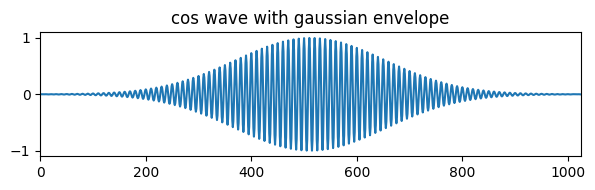

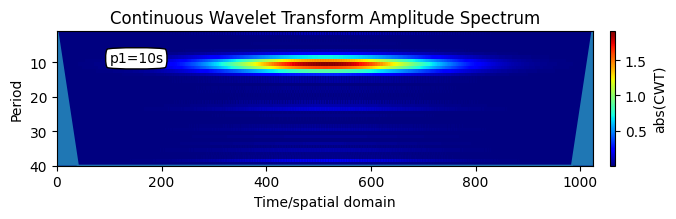

In [37]:
# let consider a timeline with 1 sample / second
ns   = 1024
time = np.arange(ns)

# and a range of scales to perform the transform
scales = scg.periods2scales( np.arange(1, 40) )

# and a periodic signal with varying amplitude
p1=10; periodic1 = np.cos(2*np.pi/p1*time) * np.exp(-((time-ns/2)/200)**2)

# plot the signal 
fig1, ax1 = plt.subplots(1, 1, figsize=(6.2,2));  
lines = ax1.plot(periodic1); 
ax1.set_xlim(0, len(time))
ax1.set_title("cos wave with gaussian envelope")
fig1.tight_layout()

# and the scaleogram
# if coikw={'alpha':1.} isn't included there's an error with alpha in plotting
ax2 = scg.cws(periodic1, scales=scales, figsize=(6.9,2.3), coikw={'alpha':1.}) 
txt = ax2.annotate("p1=10s", xy=(100, 10), bbox=dict(boxstyle="round4", fc="w"))
plt.tight_layout()

# print("Default wavelet function used to compute the transform:", scg.get_default_wavelet(), "(",
#       pywt.ContinuousWavelet(scg.get_default_wavelet()).family_name, ")")

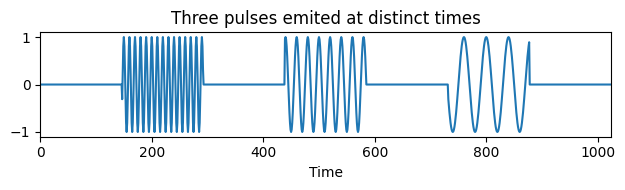

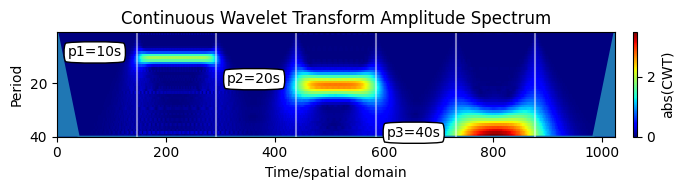

In [38]:
pulses = np.zeros(ns, dtype=np.float32)
steps  = np.linspace(0, ns, 8)
periods = [10, 20, 40]
for i in range(0,3):
    step_mask = (time > steps[i*2+1]) & (time < steps[i*2+2])
    pulses += np.cos(2*np.pi/periods[i]*time) * step_mask

# plot the pulses
fig1, ax1 = plt.subplots(1, 1, figsize=(6.5,2));  
lines = ax1.plot(pulses); ax1.set_xlim(0, len(time)); 
ax1.set_title("Three pulses emited at distinct times"); ax1.set_xlabel("Time")
fig1.tight_layout()

# and the scaleogram
ax2 = scg.cws(pulses, scales=scales, figsize=(7,2), coikw={'alpha':1.})

# add fancy helpers
for i in range(0, 3):
    txt = ax2.annotate("p%d=%ds"%(i+1,periods[i]), xy=(steps[i*2]+20, periods[i]), 
                       bbox=dict(boxstyle="round4", fc="w"))
    ax2.plot(steps[i*2+1]*np.ones(2), ax2.get_ylim(), '-w', alpha=0.5)
    ax2.plot(steps[i*2+2]*np.ones(2),   ax2.get_ylim(), '-w', alpha=0.5)
plt.tight_layout()

In [45]:
print(depth_rel_sfc)

[   0   -2   -4   -6   -8  -10  -12  -14  -16  -18  -20  -22  -24  -26
  -28  -30  -32  -34  -36  -38  -40  -42  -44  -46  -48  -50  -52  -54
  -56  -58  -60  -62  -64  -66  -68  -70  -72  -74  -76  -78  -80  -82
  -84  -86  -88  -90  -92  -94  -96  -98 -100 -102 -104 -106 -108 -110
 -112 -114 -116 -118 -120 -122 -124 -126 -128 -130 -132 -134 -136 -138
 -140 -142 -144 -146 -148 -150 -152 -154 -156 -158 -160 -162 -164 -166
 -168 -170 -172 -174 -176 -178 -180 -182 -184 -186 -188 -190 -192 -194
 -196 -198]


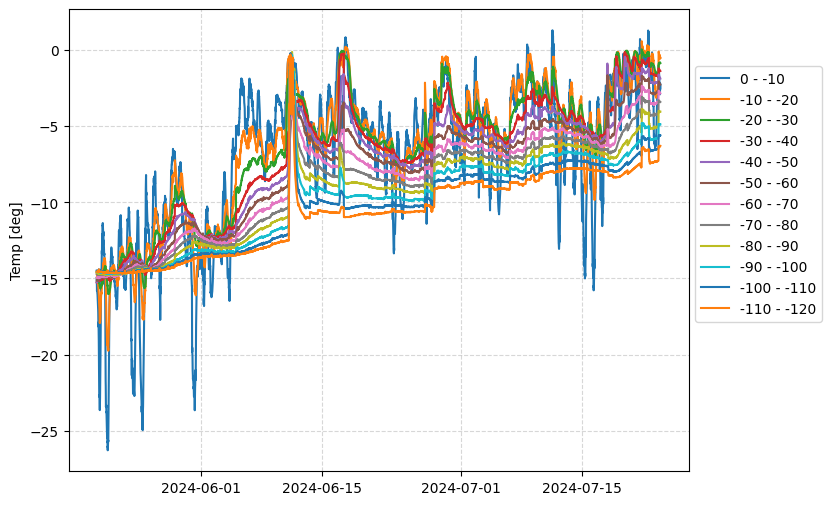

In [53]:
## try 10 cm intervals for temperature (and dT/dz?) form surface, then later narrow
intervals = np.arange(0,-121,-10) # lowest level is about where there are obs for entire season

interval_temps = {}

fig, ax = plt.subplots(1, figsize=(8,6))
for i0, i1 in zip(intervals[:-1],intervals[1:]):
    int_idx = np.where((depth_rel_sfc<=i0)&(depth_rel_sfc>i1))[0]
    int_temp = temps_rel_sfc[:, int_idx]
    # print(i0, i1, int_temp.shape, int_temp.mean(axis=1).shape)
    interval_temps[(i0, i1)] = int_temp.mean(axis=1)
    plt.plot(simba_dates, interval_temps[(i0, i1)], label=f'{i0} - {i1}')

plt.grid(alpha=.5, ls='--')
plt.ylabel('Temp [deg]')
plt.legend(loc='center left', bbox_to_anchor=(1,.6))
plt.show()
# temps_rel_sfc

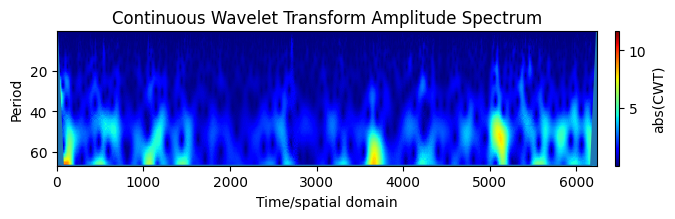

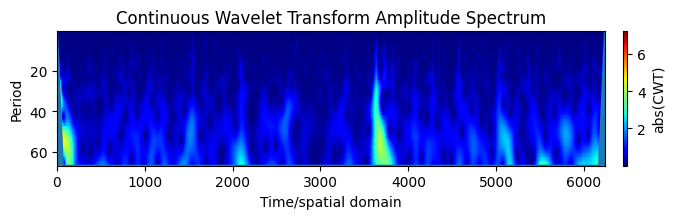

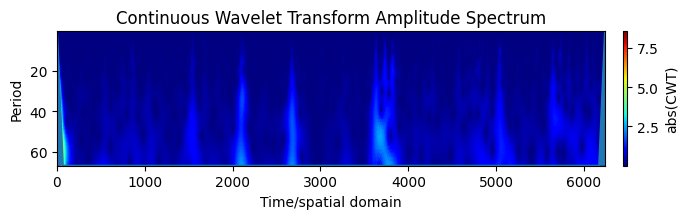

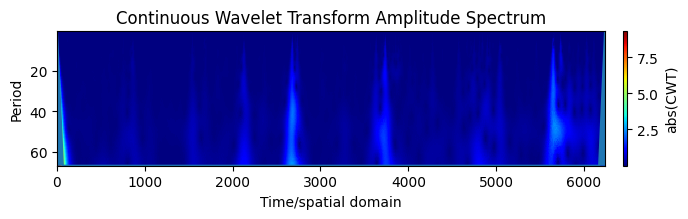

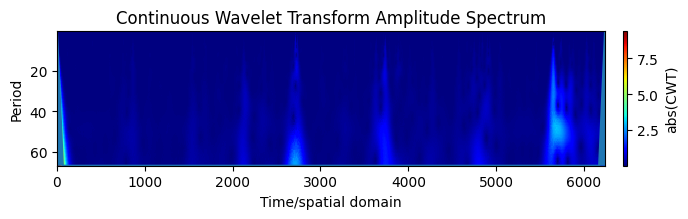

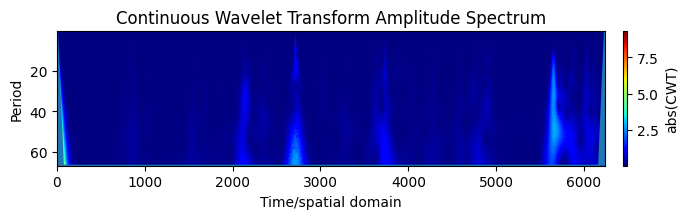

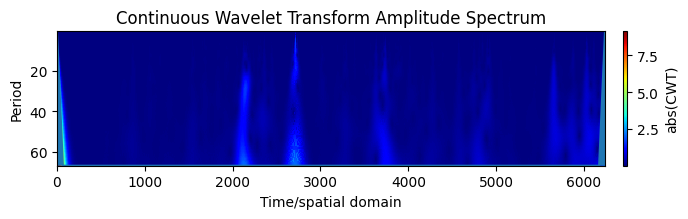

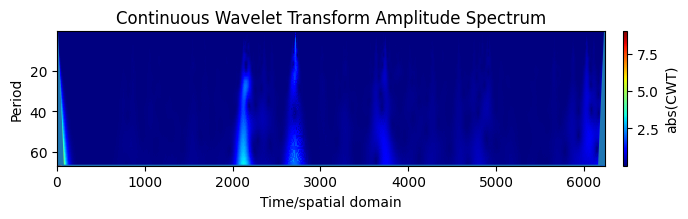

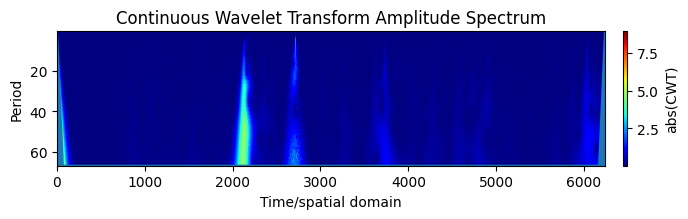

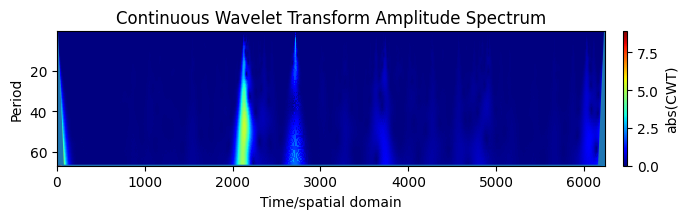

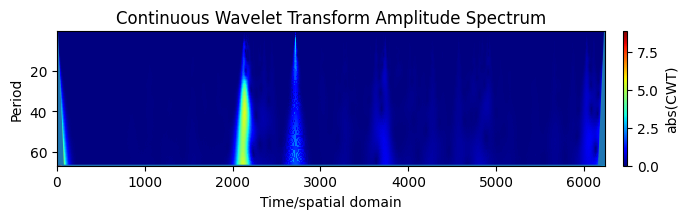

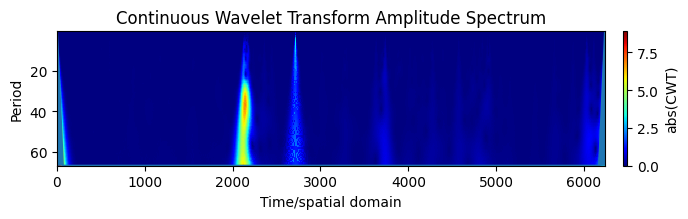

In [54]:
# and a range of scales to perform the transform
scales = scg.periods2scales( np.arange(1, 40) ) # not sure how to adjust this

for i0, i1 in zip(intervals[:-1],intervals[1:]):
    ax2 = scg.cws(interval_temps[(i0, i1)], figsize=(6.9,2.3), coikw={'alpha':1.}) #, scales=scales
    plt.tight_layout()
    plt.show()